# Báo cáo bài tập thực hành tuần 3
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

Import các thư viện cần thiết

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA

### 1. Viết chương trình tính khoảng cách edit

In [35]:
def find_minimum_edit_distance(source_string, target_string):
    m = len(source_string)
    n = len(target_string)
    dp = [[0]*(m + 1) for i in range(n + 1)]
    
    for i in range(1, n + 1):
        dp[i][0] = dp[i - 1][0] + 1
        
    for i in range(1, m + 1):
        dp[0][i] = dp[0][i - 1] + 1
        
    operations_performed = []
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if source_string[j - 1] == target_string[i-1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = min(dp[i - 1][j] + 1,
                               dp[i - 1][j - 1] + 2,
                               dp[i][j - 1] + 1)
                               
    i = n
    j = m
    while (i != 0 and j != 0):
        if target_string[i-1] == source_string[j-1]:
            i -= 1
            j -= 1
        else:
            if dp[i][j] == dp[i - 1][j - 1]+2:
                operations_performed.append(
                    ('SUBSTITUTE', source_string[j-1], target_string[i - 1]))
                i -= 1
                j -= 1
            elif dp[i][j] == dp[i - 1][j]+1:
                operations_performed.append(('INSERT', target_string[i - 1]))
                i -= 1
            else:
                operations_performed.append(('DELETE', source_string[j - 1]))
                j -= 1
                
    while (j != 0):
        operations_performed.append(('DELETE', source_string[j-1]))
        j -= 1
        
    while (i != 0):
        operations_performed.append(('INSERT', target_string[i-1]))
        i -= 1
        
    operations_performed.reverse()
    return [dp[n][m], operations_performed]

In [36]:
input1 = "rizz"
target1= "rizzler"
print(find_minimum_edit_distance(input1, target1))

input2 = "skibidi"
target2 = "skib"
print(find_minimum_edit_distance(input2, target2))

input3 = "bruh"
target3 = "brah"
print(find_minimum_edit_distance(input3, target3))

input4 = "sus"
target4 = "buss"
print(find_minimum_edit_distance(input4, target4))

input6 = "wibu"
target6 = "simp"
print(find_minimum_edit_distance(input6, target6))

input7 = "sigma"
target7 = "ligma"
print(find_minimum_edit_distance(input7, target7))

[3, [('INSERT', 'l'), ('INSERT', 'e'), ('INSERT', 'r')]]
[3, [('DELETE', 'i'), ('DELETE', 'd'), ('DELETE', 'i')]]
[2, [('SUBSTITUTE', 'u', 'a')]]
[3, [('SUBSTITUTE', 's', 'b'), ('INSERT', 's')]]
[6, [('SUBSTITUTE', 'w', 's'), ('SUBSTITUTE', 'b', 'm'), ('SUBSTITUTE', 'u', 'p')]]
[2, [('SUBSTITUTE', 's', 'l')]]


Hàm `find_minimum_edit_distance` nhận vào hai chuỗi `source_string` và `target_string`, sau đó sử dụng thuật toán quy hoạch động để tính khoảng cách edit giữa chúng. Kết quả trả về là một danh sách gồm khoảng cách edit tối thiểu và danh sách các thao tác đã thực hiện để chuyển đổi `source_string` thành `target_string`.

Lúc đầu, chúng ta khởi tạo một ma trận `dp` có kích thước `(n+1) x (m+1)` để lưu trữ khoảng cách edit giữa các phần tử con của hai chuỗi. Sau đó, chúng ta điền vào ma trận này dựa trên các quy tắc của thuật toán edit distance.

```python
dp = [[0]*(m + 1) for i in range(n + 1)]
```
Tiếp theo, chúng ta điền vào hàng đầu tiên và cột đầu tiên của ma trận `dp` để xử lý các trường hợp khi một trong hai chuỗi rỗng. Rồi chúng ta điền đầy đủ ma trận `dp` bằng cách so sánh từng ký tự của hai chuỗi và áp dụng các quy tắc của thuật toán edit distance. Cuối cùng, chúng ta truy vết lại các thao tác đã thực hiện để chuyển đổi `source_string` thành `target_string` và trả về kết quả.

```python
for i in range(1, n + 1):
    dp[i][0] = dp[i - 1][0] + 1
for i in range(1, m + 1):
    dp[0][i] = dp[0][i - 1] + 1

for i in range(1, n + 1):
    for j in range(1, m + 1):
        if source_string[j - 1] == target_string[i-1]:
            dp[i][j] = dp[i - 1][j - 1]
        else:
            dp[i][j] = min(dp[i - 1][j] + 1,
                           dp[i - 1][j - 1] + 2,
                           dp[i][j - 1] + 1)

```
Sau khi điền đầy đủ ma trận `dp`, chúng ta sẽ truy vết lại các thao tác đã thực hiện để chuyển đổi `source_string` thành `target_string`. Chúng ta bắt đầu từ ô cuối cùng của ma trận và di chuyển ngược về phía ô đầu tiên, xác định thao tác nào đã được thực hiện dựa trên giá trị trong ma trận.
```python
i = n
j = m
while (i != 0 and j != 0):
    if target_string[i-1] == source_string[j-1]:
        i -= 1
        j -= 1
    else:
        if dp[i][j] == dp[i - 1][j - 1]+2:
            operations_performed.append(
                ('SUBSTITUTE', source_string[j-1], target_string[i - 1]))
            i -= 1
            j -= 1
        elif dp[i][j] == dp[i - 1][j]+1:
            operations_performed.append(('INSERT', target_string[i - 1]))
            i -= 1
        else:
            operations_performed.append(('DELETE', source_string[j - 1]))
            j -= 1
```
Cuối cùng, chúng ta xử lý các trường hợp còn lại khi một trong hai chuỗi đã được duyệt hết và trả về kết quả.
```python
while (j != 0):
    operations_performed.append(('DELETE', source_string[j-1]))
    j -= 1
while (i != 0):
    operations_performed.append(('INSERT', target_string[i-1]))
    i -= 1
operations_performed.reverse()
return [dp[n][m], operations_performed]
```

### 2. Viết chương trình tính khoảng cách dãy con chung dài nhất

In [37]:
def LCSS(start, end):
    m = len(start)
    n = len(end)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    common_string = ''

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if start[j - 1] == end[i - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
                
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    i = n
    j = m
    while i != 0 and j != 0:
        if start[j - 1] == end[i - 1]:
            common_string += start[j - 1]
            i -= 1
            j -= 1
            
        elif dp[i - 1][j] > dp[i][j - 1]:
            i -= 1
            
        else:
            j -= 1

    return dp[n][m], common_string[::-1]

In [38]:
input1 = "skibidi"
target1 = "skibidi"
print(LCSS(input1, target1))

input2 = "sigma"
target2 = "uwu"
print(LCSS(input2, target2))

input3 = "ohio"
target3 = "bro"
print(LCSS(input3, target3))

input4 = "bussin"
target4 = "sussy"
print(LCSS(input4, target4))

input5 = "wompwomp"
target5 = "womp womp"
print(LCSS(input5, target5))

input6 = "mao mao"
target6 = "lmao"
print(LCSS(input6, target6))

input7 = "sigma"
target7 = "ligmaballs"
print(LCSS(input7, target7))

(7, 'skibidi')
(0, '')
(1, 'o')
(3, 'uss')
(8, 'wompwomp')
(3, 'mao')
(4, 'igma')


Hàm `LCSS` nhận vào hai chuỗi `start` và `end`, sau đó sử dụng thuật toán quy hoạch động để tính độ dài của dãy con chung dài nhất giữa hai chuỗi. Kết quả trả về là một tuple gồm độ dài của dãy con chung dài nhất và chính dãy con đó. 

Bước đầu tiên, chúng ta khởi tạo một ma trận `dp` có kích thước `(n+1) x (m+1)` để lưu trữ độ dài của dãy con chung dài nhất giữa các phần tử con của hai chuỗi. 
```python
dp = [[0] * (m + 1) for _ in range(n + 1)]
```
Sau đó, chúng ta điền đầy đủ ma trận `dp` bằng cách so sánh từng ký tự của hai chuỗi và áp dụng các quy tắc của thuật toán dãy con chung dài nhất. 
```python
for i in range(1, n + 1):
    for j in range(1, m + 1):
        if start[j - 1] == end[i - 1]:
            dp[i][j] = dp[i - 1][j - 1] + 1
            
        else:
            dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
```
Sau khi điền đầy đủ ma trận `dp`, chúng ta sẽ truy vết lại dãy con chung dài nhất bằng cách bắt đầu từ ô cuối cùng của ma trận và di chuyển ngược về phía ô đầu tiên, xác định các ký tự nào đã được bao gồm trong dãy con chung dựa trên giá trị trong ma trận.
```python
i = n
j = m
while i != 0 and j != 0:
    if start[j - 1] == end[i - 1]:
        common_string += start[j - 1]
        i -= 1
        j -= 1
        
    elif dp[i - 1][j] > dp[i][j - 1]:
        i -= 1
        
    else:
        j -= 1
```

Cuối cùng, chúng ta trả về độ dài của dãy con chung dài nhất và chính dãy con đó (đã được đảo ngược để đúng thứ tự).
```python
return dp[n][m], common_string[::-1]
```

### 3. Tính khoảng cách biến đổi thời gian động

In [39]:
def DTW(s1, s2):
    m = len(s1)
    n = len(s2)
    
    if m == 0 or n == 0:
        return [], []
        
    dp = [[0]*n for i in range(m)]
    dp[0][0] = abs(s1[0] - s2[0])
    
    for i in range(1, m):
        dp[i][0] = abs(s1[i] - s2[0]) + dp[i-1][0]
    for i in range(1, n):
        dp[0][i] = abs(s2[i] - s1[0]) + dp[0][i-1]

    for i in range(1, m):
        for j in range(1, n):
            dp[i][j] = abs(s1[i] - s2[j]) + \
                min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    dp = dp[::-1]

    i = 0
    j = n-1
    warp_path = [(i, j)]
    
    while i != m-1 and j != 0:
        if min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j-1]:
            warp_path.append((i+1, j-1))
            i += 1
            j -= 1
        elif min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j]:
            warp_path.append((i+1, j))
            i += 1
        else:
            warp_path.append((i, j-1))
            j -= 1

    warp_path.append((m-1, 0))
    
    return dp, warp_path

```py
def DTW(s1, s2):
    m = len(s1)
    n = len(s2)
    
    if m == 0 or n == 0:
        return [], []
        
    dp = [[0]*n for i in range(m)]
    dp[0][0] = abs(s1[0] - s2[0])
    
    for i in range(1, m):
        dp[i][0] = abs(s1[i] - s2[0]) + dp[i-1][0]
    for i in range(1, n):
        dp[0][i] = abs(s2[i] - s1[0]) + dp[0][i-1]

    for i in range(1, m):
        for j in range(1, n):
            dp[i][j] = abs(s1[i] - s2[j]) + \
                min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    dp = dp[::-1]

    i = 0
    j = n-1
    warp_path = [(i, j)]
    
    while i != m-1 and j != 0:
        if min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j-1]:
            warp_path.append((i+1, j-1))
            i += 1
            j -= 1
        elif min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j]:
            warp_path.append((i+1, j))
            i += 1
        else:
            warp_path.append((i, j-1))
            j -= 1

    warp_path.append((m-1, 0))
    
    return dp, warp_path
```
Hàm `DTW` nhận vào hai chuỗi thời gian `s1` và `s2`, sau đó sử dụng thuật toán Dynamic Time Warping (DTW) để tính khoảng cách biến đổi thời gian giữa chúng. Kết quả trả về là một tuple gồm ma trận DTW và đường đi tối ưu (warp path) giữa hai chuỗi.

Tương tự như các thuật toán trước, chúng ta khởi tạo một ma trận `dp` để lưu trữ khoảng cách biến đổi thời gian giữa các phần tử con của hai chuỗi.
```python
dp = [[0]*n for i in range(m)]

```
Sau đó chúng ta điền đầy đủ ma trận `dp` bằng cách so sánh từng phần tử của hai chuỗi và áp dụng các quy tắc của thuật toán DTW. 

```python
for i in range(1, m):
    dp[i][0] = abs(s1[i] - s2[0]) + dp[i-1][0]
for i in range(1, n):
    dp[0][i] = abs(s2[i] - s1[0]) + dp[0][i-1]

for i in range(1, m):
    for j in range(1, n):
        dp[i][j] = abs(s1[i] - s2[j]) + \
            min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
```

Sau khi điền đầy đủ ma trận `dp`, chúng ta sẽ truy vết lại đường đi tối ưu (warp path) bằng cách bắt đầu từ ô cuối cùng của ma trận và di chuyển ngược về phía ô đầu tiên, xác định các bước nào đã được thực hiện dựa trên giá trị trong ma trận.
```python
i = 0
j = n-1
warp_path = [(i, j)]
while i != m-1 and j != 0:
    if min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j-1]:
        warp_path.append((i+1, j-1))
        i += 1
        j -= 1
    elif min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j]:
        warp_path.append((i+1, j))
        i += 1
    else:
        warp_path.append((i, j-1))
        j -= 1

```

Cuối cùng, chúng ta thêm điểm cuối cùng vào đường đi tối ưu và trả về ma trận DTW cùng với đường đi đó.
```python
warp_path.append((m-1, 0))
return dp, warp_path
```

In [40]:
def plotpath(cost_matrix, warp_path):
    cost_matrix = np.array(cost_matrix)
    rows, cols = cost_matrix.shape

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(cost_matrix, cmap="Reds")

    threshold = cost_matrix.max() / 2.0
    for i in range(rows):
        for j in range(cols):
            val = cost_matrix[i, j]
            text_color = "white" if val > threshold else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=text_color)

    ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))

    path_x = [p[1] for p in warp_path]
    path_y = [p[0] for p in warp_path]

    ax.plot(path_x, path_y, color='red', linewidth=3, alpha=0.5)
    plt.show()

Hàm bổ sung để mô phỏng đường đi tối ưu trên ma trận DTW. Hàm `plotpath` nhận vào ma trận chi phí (cost matrix) và đường đi tối ưu (warp path), sau đó sử dụng thư viện Matplotlib để vẽ ma trận chi phí dưới dạng một hình ảnh và đánh dấu các giá trị trong ma trận.

Hàm này hoạt đông bằng cách tạo một biểu đồ với ma trận chi phí được hiển thị dưới dạng màu sắc. 
```py
im = ax.imshow(cost_matrix, cmap="Reds")
```
Sau đó, chúng ta thêm các giá trị của ma trận vào từng ô của biểu đồ để dễ dàng quan sát.
```py
threshold = cost_matrix.max() / 2.0
for i in range(rows):
    for j in range(cols):
        val = cost_matrix[i, j]
        text_color = "white" if val > threshold else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=text_color)
```
Tiếp theo, chúng ta thêm các đường lưới để phân tách rõ ràng giữa các ô của ma trận.
```py
ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_xticks(np.arange(cols))
ax.set_yticks(np.arange(rows))
```
Cuối cùng, chúng ta vẽ đường đi tối ưu (warp path) trên biểu đồ bằng cách lấy các tọa độ từ `warp_path` và sử dụng hàm `plot` của Matplotlib để vẽ đường đó.
```py
path_x = [p[1] for p in warp_path]
path_y = [p[0] for p in warp_path]
ax.plot(path_x, path_y, color='red', linewidth=3, alpha=0.5)
plt.show()
```



([[1]], [(0, 0), (0, 0)])
([], [])


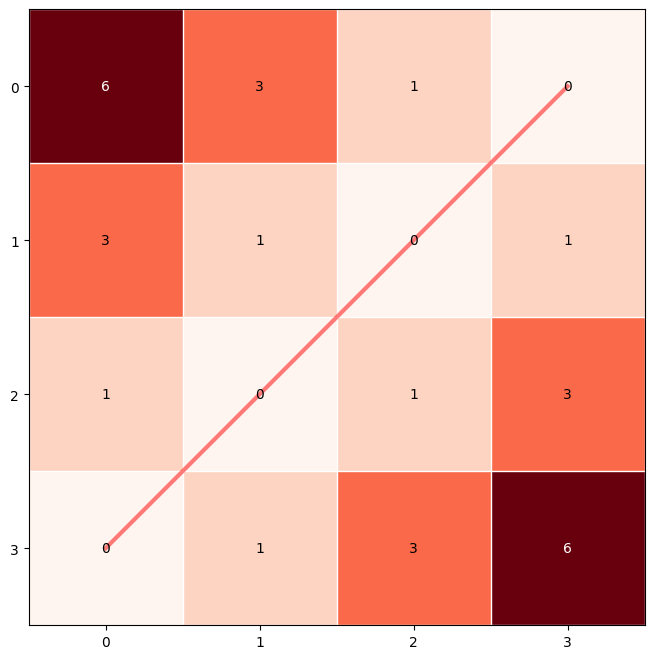

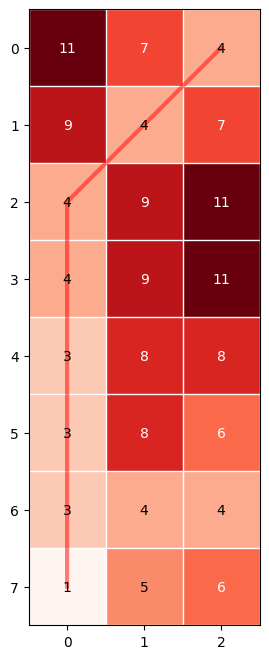

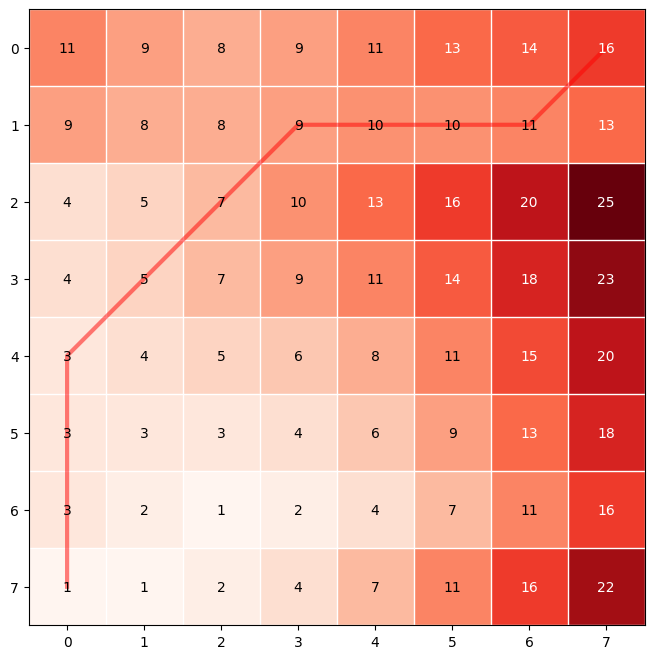

In [41]:
s1 = [1]
s2 = [2]
print(DTW(s1, s2))

s1 = []
s2 = [1, 2, 3, 4]
print(DTW(s1, s2))

s1 = [1, 2, 3, 4]
s2 = [1, 2, 3, 4]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)

s1 = [1, 2, 3, 4]
s2 = [5, 6, 7, 8 , 9]
cost_matrix, warp_path = DTW(s1, s2)

s1 = [2, 3, 1, 1, 0, 1, 6 ,3]
s2 = [1, 6, 3]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)

s1 = [2, 3, 1, 1, 0, 1, 6 ,3]
s2 = [1, 2, 3, 4, 5, 6, 7, 8]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)